# Retrospective pKYC Evaluation

Este notebook convierte los resultados del motor pKYC en gráficos para PowerPoint.

La pregunta original es: **¿detectamos el riesgo antes de que el fraude/sanción fuera públicamente conocido?**

Respuesta corta con el dataset actual: **no todavía de forma defendible**. Lo que sí demuestra bien el sistema es:

- detección fuerte el mismo día del evento público en varios casos;
- early stop tras 1 evento en la mayoría de alarmas;
- explicabilidad por contribuidores topológicos;
- una brecha clara de datos para convertirlo en un backtest histórico real.

> Importante: esta evaluación usa el snapshot actual de `data/risk_profiling.db` y `data/evaluation_lead_time.json`. No es un backtest regulatorio con snapshots históricos "as-of".

In [1]:
from __future__ import annotations

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EVAL_JSON = ROOT / "data" / "evaluation_lead_time.json"
DB_PATH = ROOT / "data" / "risk_profiling.db"
FIG_DIR = ROOT / "data" / "ppt_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6.5),
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

COLORS = {
    "navy": "#1f3a5f",
    "blue": "#2f80ed",
    "green": "#2e7d32",
    "amber": "#b7791f",
    "red": "#c62828",
    "gray": "#6b7280",
    "light_gray": "#e5e7eb",
}

def legend_below(ax, ncol=2, fontsize=10):
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=ncol,
        fontsize=fontsize,
        frameon=False,
    )


def legend_right(ax, ncol=1, fontsize=10):
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        ncol=ncol,
        fontsize=fontsize,
        frameon=False,
    )


def savefig(name: str, bottom=0.12, right=0.98):
    path = FIG_DIR / f"{name}.png"
    fig = plt.gcf()
    fig.subplots_adjust(bottom=bottom, right=right)
    fig.tight_layout()
    plt.savefig(path, bbox_inches="tight", transparent=False)
    print(f"saved: {path.relative_to(ROOT)}")

In [2]:
with EVAL_JSON.open("r", encoding="utf-8") as f:
    payload = json.load(f)

cases = pd.DataFrame(payload["cases"])

# Short labels for chart readability
label_map = {
    "Wirecard AG": "Wirecard",
    "FTX Trading Ltd": "FTX",
    "MicroStrategy Incorporated": "MicroStrategy",
    "VTB Bank": "VTB",
    "Gazprombank": "Gazprombank",
    "Surgutneftegas": "Surgut",
    "OpenAI": "OpenAI",
}
cases["short_label"] = cases["label"].map(label_map).fillna(cases["label"])
cases["trigger_date"] = pd.to_datetime(cases["trigger_timestamp"], errors="coerce").dt.date
cases["reference_date_dt"] = pd.to_datetime(cases["reference_date"], errors="coerce").dt.date
cases["risk_label"] = cases["max_combined_risk"].map(lambda x: f"{x:.3f}" if pd.notna(x) and x else "—")

summary = {
    "cases": len(cases),
    "alarms": int(cases["alarm_fired"].sum()),
    "same_day": int((cases["status"] == "same_day").sum()),
    "late": int((cases["status"] == "late").sum()),
    "no_alarm": int((cases["status"] == "no_alarm").sum()),
    "one_event_alarms": int(((cases["alarm_fired"]) & (cases["events_seen"] == 1)).sum()),
    "avg_alarm_risk": cases.loc[cases["alarm_fired"], "max_combined_risk"].mean(),
}
summary, cases[["short_label", "case_type", "reference_date", "trigger_date", "lead_days", "status", "max_combined_risk", "events_seen", "events_passed_triage"]]

({'cases': 7,
  'alarms': 6,
  'same_day': 4,
  'late': 2,
  'no_alarm': 1,
  'one_event_alarms': 5,
  'avg_alarm_risk': np.float64(0.8398166666666667)},
      short_label                       case_type reference_date trigger_date  \
 0       Wirecard              fraud / insolvency     2020-06-25   2020-06-25   
 1            FTX              fraud / bankruptcy     2022-11-11   2022-11-11   
 2  MicroStrategy                  semantic drift     2020-08-11   2025-05-20   
 3            VTB                       sanctions     2022-02-24   2022-02-25   
 4    Gazprombank      sanctions / state exposure     2022-03-12   2022-03-12   
 5         Surgut                       sanctions     2025-01-10          NaT   
 6         OpenAI  regulatory / safety litigation     2026-06-01   2026-06-01   
 
    lead_days    status  max_combined_risk  events_seen  events_passed_triage  
 0        0.0  same_day             0.8343            1                     1  
 1        0.0  same_day             

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    earliest_adverse = pd.read_sql_query(
        """
        SELECT
            c.legal_name AS label,
            MIN(date(n.published_at)) AS earliest_adverse_date,
            COUNT(*) AS adverse_articles
        FROM companies c
        LEFT JOIN news_articles n
          ON n.company_id = c.id
         AND n.adverse_score > 0
        GROUP BY c.legal_name
        """,
        conn,
    )

cases = cases.merge(earliest_adverse, on="label", how="left")
cases["earliest_adverse_date_dt"] = pd.to_datetime(cases["earliest_adverse_date"], errors="coerce").dt.date
cases["earliest_adverse_lead_days"] = (
    pd.to_datetime(cases["reference_date_dt"]) - pd.to_datetime(cases["earliest_adverse_date_dt"])
).dt.days

cases[["short_label", "reference_date", "trigger_date", "lead_days", "earliest_adverse_date", "earliest_adverse_lead_days", "adverse_articles"]]

,short_label,reference_date,trigger_date,lead_days,earliest_adverse_date,earliest_adverse_lead_days,adverse_articles
0,Wirecard,2020-06-25,2020-06-25,0.0,2020-06-25,0,14
1,FTX,2022-11-11,2022-11-11,0.0,2022-11-11,0,18
2,MicroStrategy,2020-08-11,2025-05-20,-1743.0,2024-06-06,-1395,4
3,VTB,2022-02-24,2022-02-25,-1.0,2018-05-31,1365,23
4,Gazprombank,2022-03-12,2022-03-12,0.0,2022-03-12,0,22
5,Surgut,2025-01-10,NaT,NaN,2014-09-26,3759,21
6,OpenAI,2026-06-01,2026-06-01,0.0,2026-03-25,68,22


saved: data/ppt_figures/01_status_and_risk.png


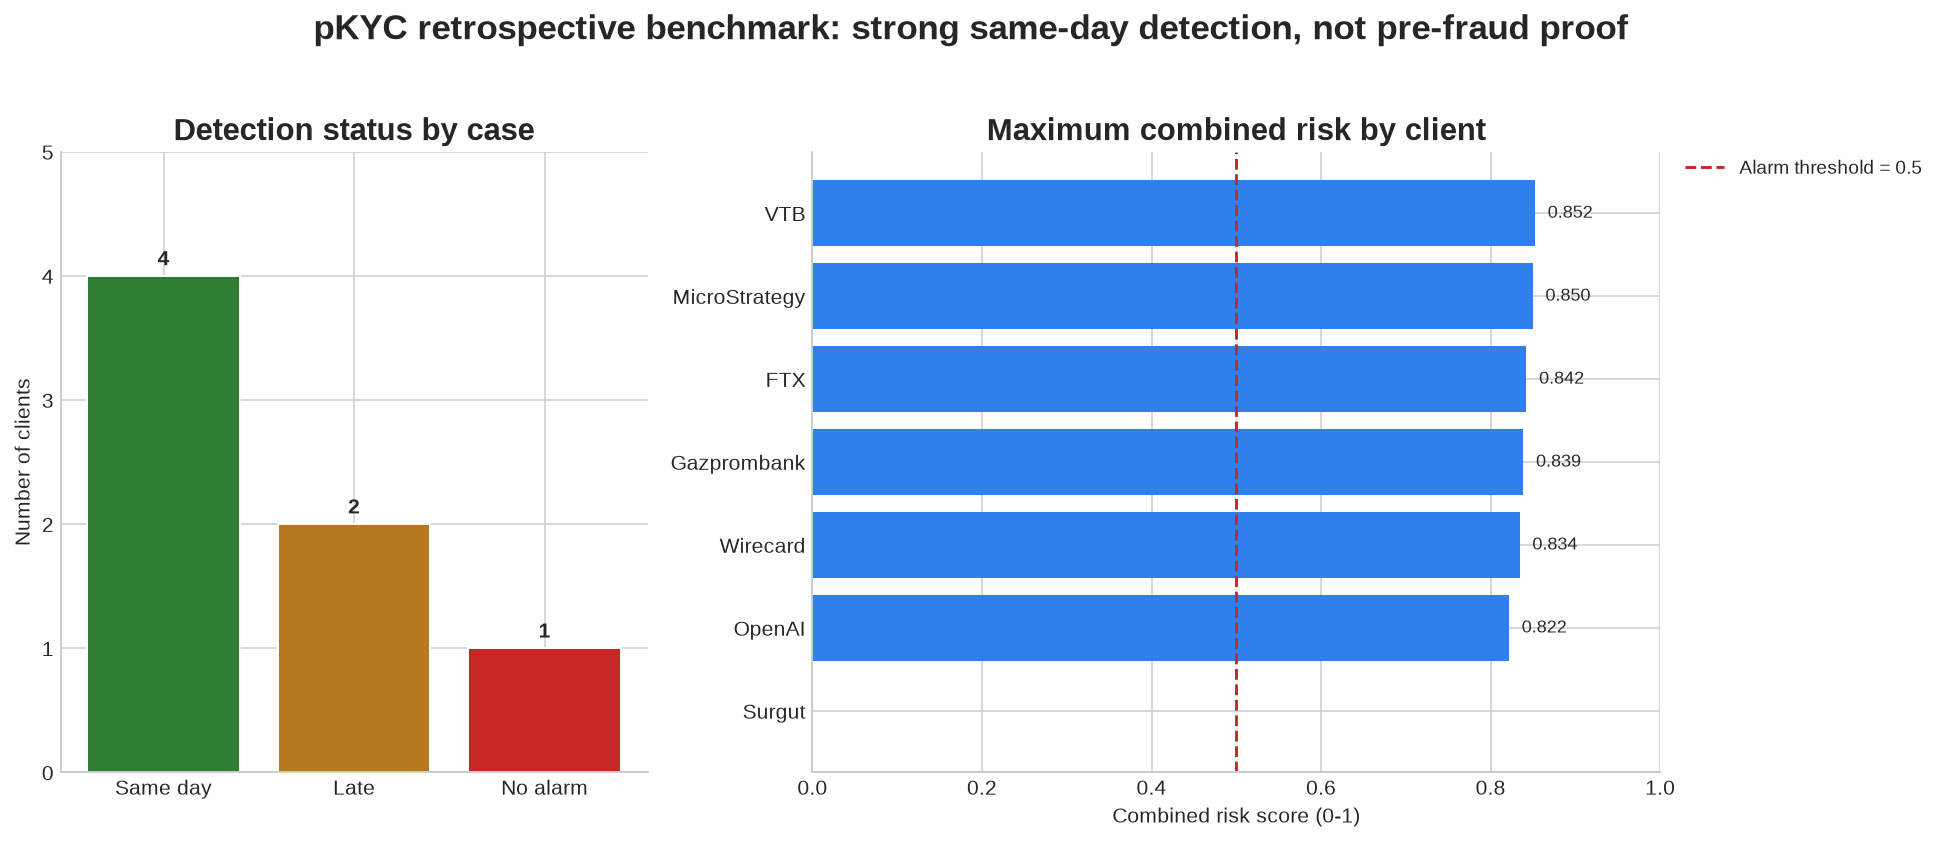

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [0.9, 1.3]})

status_order = ["same_day", "late", "no_alarm"]
status_labels = ["Same day", "Late", "No alarm"]
status_colors = [COLORS["green"], COLORS["amber"], COLORS["red"]]
status_counts = cases["status"].value_counts().reindex(status_order, fill_value=0)

axes[0].bar(status_labels, status_counts.values, color=status_colors, edgecolor="white", linewidth=1)
axes[0].set_title("Detection status by case")
axes[0].set_ylabel("Number of clients")
axes[0].set_ylim(0, max(status_counts.max() + 1, 4))
for idx, value in enumerate(status_counts.values):
    axes[0].text(idx, value + 0.05, str(value), ha="center", va="bottom", fontweight="bold")

plot_df = cases.sort_values("max_combined_risk", ascending=True)
colors = [COLORS["red"] if s == "no_alarm" else COLORS["blue"] for s in plot_df["status"]]
axes[1].barh(plot_df["short_label"], plot_df["max_combined_risk"], color=colors)
axes[1].axvline(0.5, color=COLORS["red"], linestyle="--", linewidth=1.5, label="Alarm threshold = 0.5")
axes[1].set_title("Maximum combined risk by client")
axes[1].set_xlabel("Combined risk score (0-1)")
axes[1].set_xlim(0, 1)
legend_right(axes[1])
for y, value in enumerate(plot_df["max_combined_risk"]):
    if value > 0:
        axes[1].text(value + 0.015, y, f"{value:.3f}", va="center", fontsize=9)

fig.suptitle("pKYC retrospective benchmark: strong same-day detection, not pre-fraud proof", y=1.03, fontsize=18, fontweight="bold")
savefig("01_status_and_risk", right=0.82)
plt.show()

saved: data/ppt_figures/02_lead_time.png


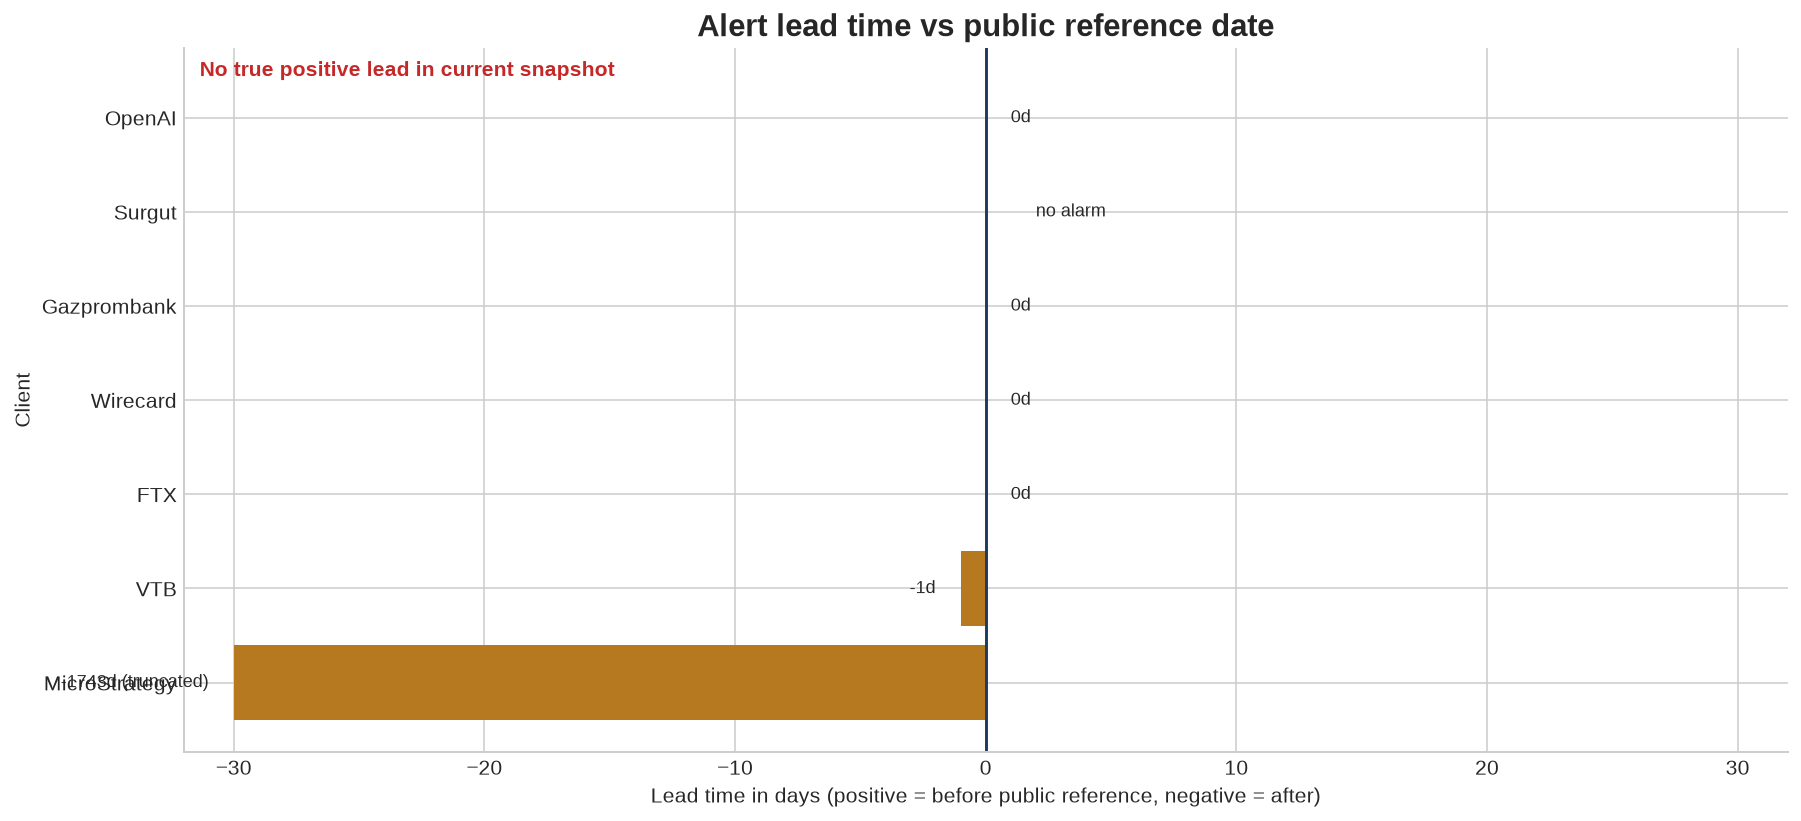

In [5]:
lead_df = cases.copy()
lead_df["lead_days_plot"] = lead_df["lead_days"].fillna(0).clip(lower=-30, upper=30)
lead_df = lead_df.sort_values("lead_days_plot")
bar_colors = []
for _, row in lead_df.iterrows():
    if row["status"] == "same_day":
        bar_colors.append(COLORS["green"])
    elif row["status"] == "late":
        bar_colors.append(COLORS["amber"])
    else:
        bar_colors.append(COLORS["red"])

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(lead_df["short_label"], lead_df["lead_days_plot"], color=bar_colors)
ax.axvline(0, color=COLORS["navy"], linewidth=1.5)
ax.set_title("Alert lead time vs public reference date")
ax.set_xlabel("Lead time in days (positive = before public reference, negative = after)")
ax.set_ylabel("Client")
ax.set_xlim(-32, 32)

for y, (_, row) in enumerate(lead_df.iterrows()):
    if pd.isna(row["lead_days"]):
        label = "no alarm"
        x = 1
    elif row["lead_days"] < -30:
        label = f"{int(row['lead_days'])}d (truncated)"
        x = -30
    else:
        label = f"{int(row['lead_days'])}d"
        x = row["lead_days_plot"]
    ax.text(x + (1 if x >= 0 else -1), y, label, va="center", ha="left" if x >= 0 else "right", fontsize=9)

ax.text(0.01, 0.96, "No true positive lead in current snapshot", transform=ax.transAxes, color=COLORS["red"], fontweight="bold")
savefig("02_lead_time")
plt.show()

saved: data/ppt_figures/03_osint_vs_engine_lead.png


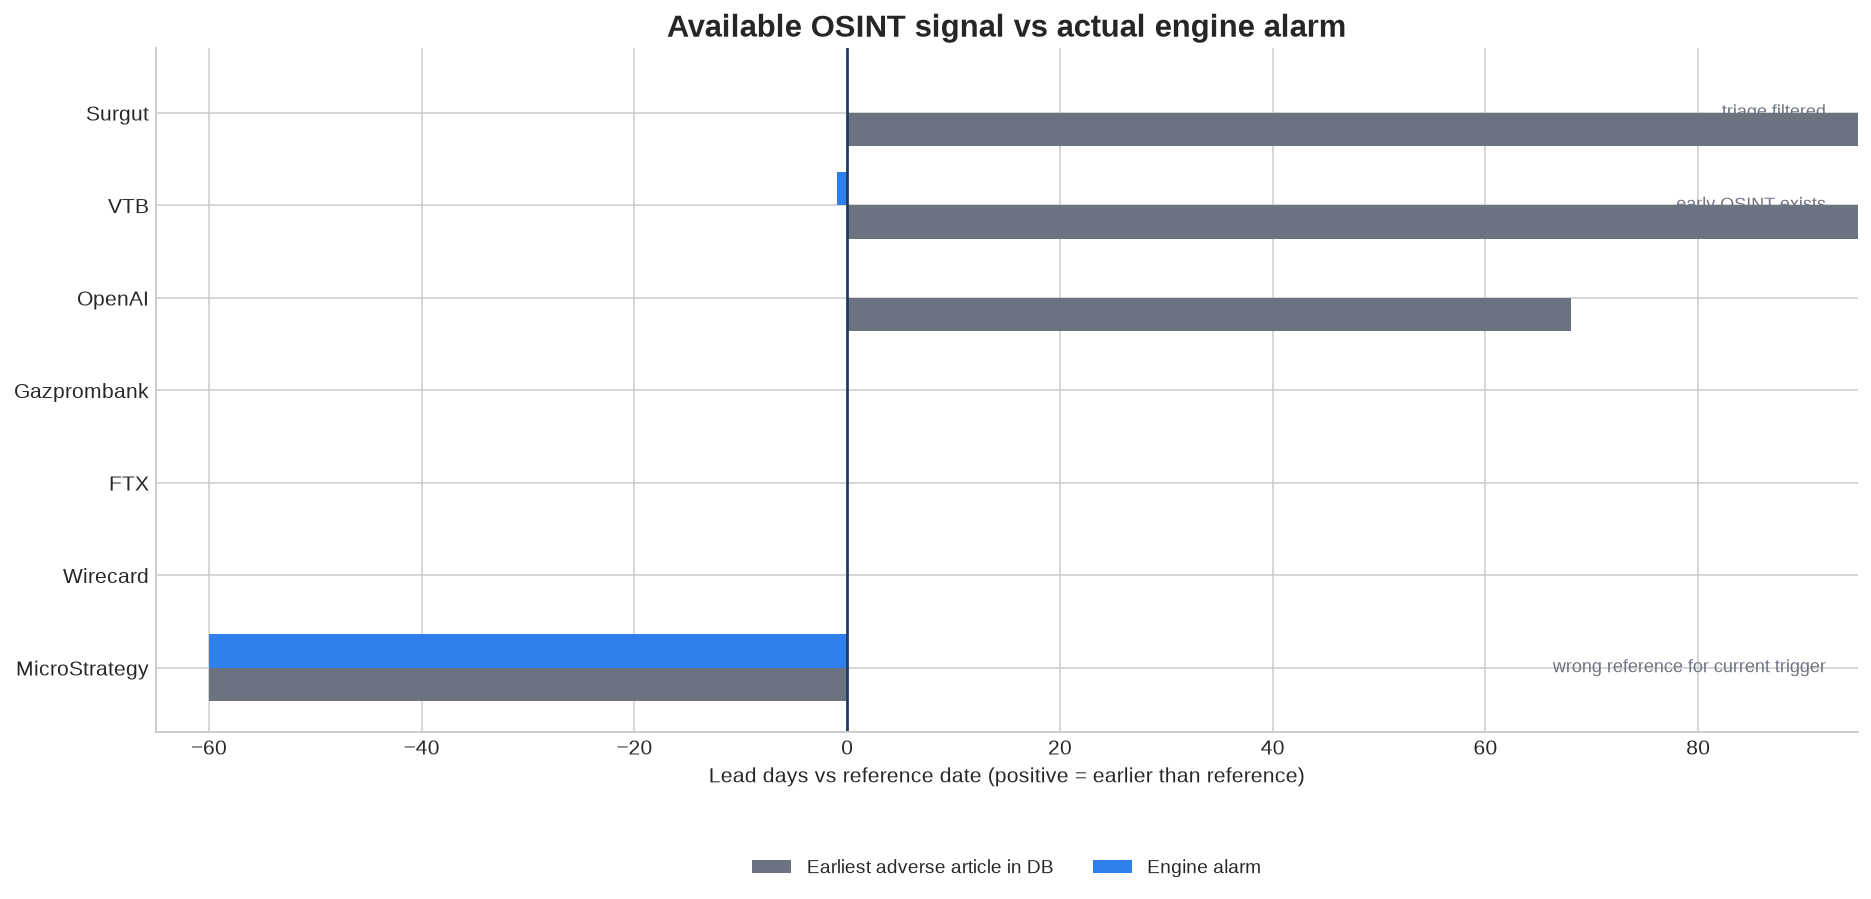

In [6]:
compare_df = cases.copy()
compare_df["engine_lead"] = compare_df["lead_days"].fillna(np.nan)
compare_df["osint_lead"] = compare_df["earliest_adverse_lead_days"]
compare_df = compare_df.sort_values("osint_lead")

fig, ax = plt.subplots(figsize=(13.5, 6.5))
y = np.arange(len(compare_df))
height = 0.36
ax.barh(y - height/2, compare_df["osint_lead"].fillna(0).clip(-60, 120), height, label="Earliest adverse article in DB", color=COLORS["gray"])
ax.barh(y + height/2, compare_df["engine_lead"].fillna(0).clip(-60, 120), height, label="Engine alarm", color=COLORS["blue"])
ax.axvline(0, color=COLORS["navy"], linewidth=1.4)
ax.set_yticks(y)
ax.set_yticklabels(compare_df["short_label"])
ax.set_xlabel("Lead days vs reference date (positive = earlier than reference)")
ax.set_title("Available OSINT signal vs actual engine alarm")
legend_below(ax, ncol=2)
ax.set_xlim(-65, 95)

notes = {
    "Surgut": "triage filtered",
    "VTB": "early OSINT exists",
    "MicroStrategy": "wrong reference for current trigger",
}
for i, (_, row) in enumerate(compare_df.iterrows()):
    note = notes.get(row["short_label"], "")
    if note:
        ax.text(92, i, note, va="center", ha="right", fontsize=9, color=COLORS["gray"])

savefig("03_osint_vs_engine_lead", bottom=0.18)
plt.show()

saved: data/ppt_figures/04_efficiency.png


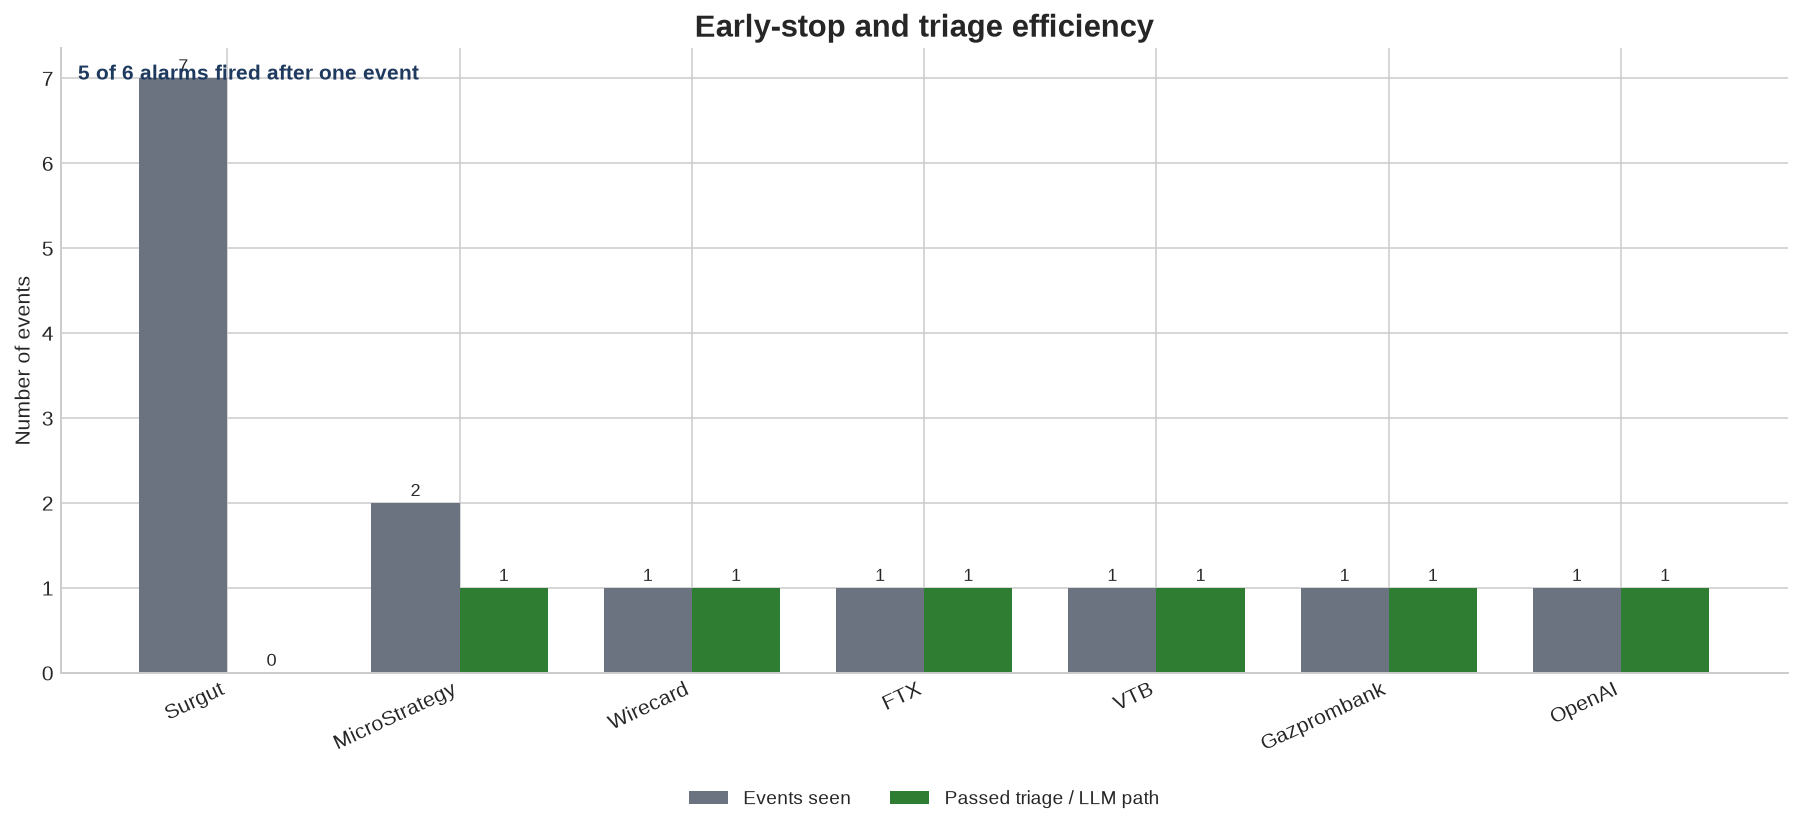

In [7]:
eff_df = cases.sort_values("events_seen", ascending=False)
x = np.arange(len(eff_df))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2, eff_df["events_seen"], width, label="Events seen", color=COLORS["gray"])
ax.bar(x + width/2, eff_df["events_passed_triage"], width, label="Passed triage / LLM path", color=COLORS["green"])
ax.set_xticks(x)
ax.set_xticklabels(eff_df["short_label"], rotation=25, ha="right")
ax.set_ylabel("Number of events")
ax.set_title("Early-stop and triage efficiency")
legend_below(ax, ncol=2)

for idx, row in enumerate(eff_df.itertuples()):
    ax.text(idx - width/2, row.events_seen + 0.08, str(row.events_seen), ha="center", fontsize=9)
    ax.text(idx + width/2, row.events_passed_triage + 0.08, str(row.events_passed_triage), ha="center", fontsize=9)

ax.text(0.01, 0.95, f"{summary['one_event_alarms']} of {summary['alarms']} alarms fired after one event", transform=ax.transAxes, fontweight="bold", color=COLORS["navy"])
savefig("04_efficiency", bottom=0.2)
plt.show()

In [8]:
display_cols = [
    "short_label", "case_type", "reference_date", "trigger_date", "lead_days",
    "status", "max_combined_risk", "events_seen", "events_passed_triage",
    "earliest_adverse_date", "earliest_adverse_lead_days", "triggering_event"
]
pretty = cases[display_cols].rename(columns={
    "short_label": "Client",
    "case_type": "Case type",
    "reference_date": "Public reference date",
    "trigger_date": "Engine trigger date",
    "lead_days": "Engine lead days",
    "status": "Status",
    "max_combined_risk": "Max risk",
    "events_seen": "Events seen",
    "events_passed_triage": "Passed triage",
    "earliest_adverse_date": "Earliest adverse article in DB",
    "earliest_adverse_lead_days": "DB adverse lead days",
    "triggering_event": "Triggering event",
})
pretty

,Client,Case type,Public reference date,Engine trigger date,Engine lead days,Status,Max risk,Events seen,Passed triage,Earliest adverse article in DB,DB adverse lead days,Triggering event
0,Wirecard,fraud / insolvency,2020-06-25,2020-06-25,0.0,same_day,0.8343,1,1,2020-06-25,0,Wirecard committed 'elaborate fraud' say audit...
1,FTX,fraud / bankruptcy,2022-11-11,2022-11-11,0.0,same_day,0.8422,1,1,2022-11-11,0,BOOM: FTX Group Files for Bankruptcy - Soverei...
2,MicroStrategy,semantic drift,2020-08-11,2025-05-20,-1743.0,late,0.8497,2,1,2024-06-06,-1395,Securities Fraud Investigation Into MicroStrat...
3,VTB,sanctions,2022-02-24,2022-02-25,-1.0,late,0.8524,1,1,2018-05-31,1365,VTB Bank Georgia Hit with Int’l Sanctions - Ci...
4,Gazprombank,sanctions / state exposure,2022-03-12,2022-03-12,0.0,same_day,0.8386,1,1,2022-03-12,0,Gazprombank: The Big Russian Lender That Dodge...
5,Surgut,sanctions,2025-01-10,NaT,NaN,no_alarm,0.0000,7,0,2014-09-26,3759,NaN
6,OpenAI,regulatory / safety litigation,2026-06-01,2026-06-01,0.0,same_day,0.8217,1,1,2026-03-25,68,"OpenAI let ChatGPT aid and abet mass shooters,..."


## Interpretation for the demo

### Are these results enough for the hackathon demo?

**Yes, if we frame them correctly.** They are good for showing:

1. **Rapid reaction:** once adverse OSINT enters the stream, the engine usually fires after one processed event.
2. **Cost efficiency:** triage avoids LLM work for irrelevant events; early stop avoids processing long histories.
3. **Explainability:** top contributors identify why the alert fired (directors, sovereign exposure, legal proceeding, etc.).
4. **Global memory demo:** separate from this notebook, `VTB + Gazprombank` shows cross-client inheritance through `Government of Russia`.

### Are they enough to claim “we detected fraud before everyone else”?

**No. Not with the current data.** The current snapshot is mostly public news already close to or after the reference event. The right claim is:

> “The prototype detects high-risk public signals immediately and cheaply; a production backtest would replay historical OSINT snapshots to measure true lead time.”

### What data is missing to do the evaluation properly?

To prove detection before the fraud/sanction was publicly recognized, we need:

- **As-of historical OSINT snapshots**: what news/sanctions/registry data was available on each date, not what the current RSS search returns today.
- **Reference timelines per case**: multiple milestones, not one date. Example: first investigative article, regulator inquiry, insolvency, conviction.
- **No post-event leakage in topology**: topology risk should be based only on information available at the simulated date.
- **Temporal API/source coverage**: GDELT, LexisNexis, Factiva, OpenSanctions historical releases, SEC filings, court dockets, or archived Google News snapshots.
- **Evaluation protocol**: monthly or weekly replay windows with frozen inputs, then measure precision, recall, lead time, and false positives.

### Useful slide wording

**Strong but honest:**

> “On real public case studies, the pKYC engine fired same-day on 4/7 clients and stopped after one event in 5/6 alarms. This validates fast reaction and cost efficiency. True pre-fraud lead-time requires historical as-of data, which is the next evaluation step.”

**Do not say:**

> “The system predicted Wirecard/FTX before the market.”

That would not be supported by this dataset.

## Evidence-backed historical replay: MicroStrategy

El benchmark anterior mide reacción sobre el snapshot OSINT actual. Para demostrar **drift gradual** sin trucar la decisión, usamos un replay histórico con el **mismo pipeline que `run_demo`**:

- el JSON aporta solo hechos fechados y verificables (`date`, `title`, `source`, `url`, `evidence`);
- `semantic_signal`, `topology_signal`, `behavioral_signal` y `combined_risk` los calcula el motor;
- no usamos `semantic_signal` escrito a mano en el JSON.

Este escenario usa eventos públicos reales y fechados de MicroStrategy/Strategy/SEC:

1. capital allocation hacia activos alternativos;
2. adopción inicial de Bitcoin como treasury reserve;
3. emisión de deuda convertible para comprar Bitcoin;
4. acumulación adicional de BTC;
5. préstamo colateralizado con Bitcoin;
6. impairment y cambio de gobierno corporativo.

A diferencia de FTX/VTB, esto no es un shock único. Es una deriva estructural: enterprise BI software → leveraged Bitcoin treasury strategy.

In [9]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_scenario_demo import replay_scenario

scenario_json = ROOT / "data" / "scenario_microstrategy_result.json"
scenario_csv = ROOT / "data" / "scenario_microstrategy_result.csv"

scenario_meta = replay_scenario(ROOT / "data" / "scenarios" / "microstrategy_drift.json")
scenario_json.write_text(json.dumps(scenario_meta, ensure_ascii=False, indent=2), encoding="utf-8")

scenario = pd.DataFrame(scenario_meta["events"])
scenario.to_csv(scenario_csv, index=False)

scenario[["index", "date", "semantic_signal", "topology_signal", "behavioral_signal", "combined_risk", "trigger", "title"]]

[STREAMING EVENT 1/6] Title: MicroStrategy announces capital allocation strategy: buyback plus alternative assets including digital assets such as bitcoin | Semantic Dist: 0.4386 | Contagion Score: 0.0000 | Combined Risk: 0.1350 [TRIGGER FIRED: FALSE]
[STREAMING EVENT 2/6] Title: MicroStrategy adopts Bitcoin as primary treasury reserve asset with a $250M purchase | Semantic Dist: 0.5627 | Contagion Score: 0.0000 | Combined Risk: 0.3713 [TRIGGER FIRED: FALSE]
[STREAMING EVENT 3/6] Title: MicroStrategy closes $650M convertible note offering and intends to invest proceeds in Bitcoin | Semantic Dist: 0.5289 | Contagion Score: 0.0000 | Combined Risk: 0.5132 [TRIGGER FIRED: TRUE]
[EARLY STOP] Critical risk threshold breached (0.5132). Halting Layer-1 stream.


,index,date,semantic_signal,topology_signal,behavioral_signal,combined_risk,trigger,title
0,1,2020-07-28,0.4386,0.0,0.0,0.1350,False,MicroStrategy announces capital allocation str...
1,2,2020-08-11,0.5627,0.0,0.0,0.3713,False,MicroStrategy adopts Bitcoin as primary treasu...
2,3,2020-12-11,0.5289,0.0,0.0,0.5132,True,MicroStrategy closes $650M convertible note of...


saved: data/ppt_figures/05_microstrategy_drift_curve.png


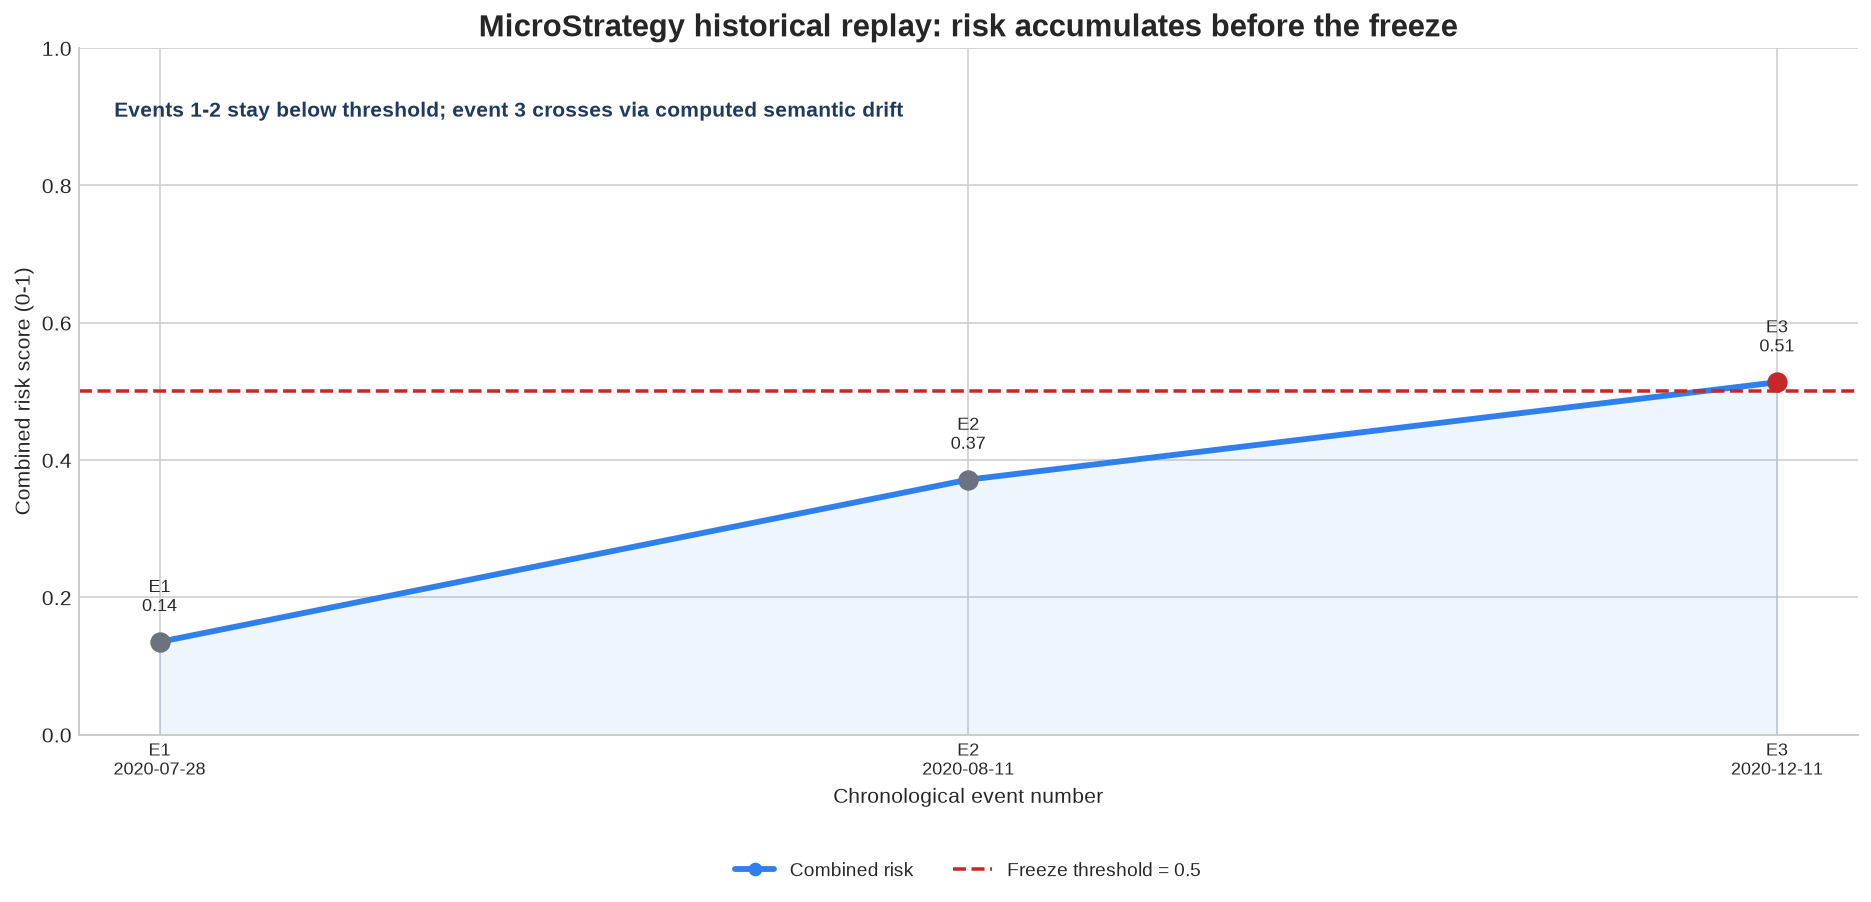

In [10]:
fig, ax = plt.subplots(figsize=(13.5, 6.5))

x = scenario["index"]
ax.plot(x, scenario["combined_risk"], marker="o", linewidth=3, color=COLORS["blue"], label="Combined risk")
ax.axhline(0.5, color=COLORS["red"], linestyle="--", linewidth=1.8, label="Freeze threshold = 0.5")
ax.fill_between(x, scenario["combined_risk"], 0, color=COLORS["blue"], alpha=0.08)

for _, row in scenario.iterrows():
    marker_color = COLORS["red"] if row["trigger"] else COLORS["gray"]
    ax.scatter(row["index"], row["combined_risk"], s=90, color=marker_color, zorder=3)
    ax.text(row["index"], row["combined_risk"] + 0.045, f"E{int(row['index'])}\n{row['combined_risk']:.2f}", ha="center", fontsize=9)

ax.set_title("MicroStrategy historical replay: risk accumulates before the freeze")
ax.set_xlabel("Chronological event number")
ax.set_ylabel("Combined risk score (0-1)")
ax.set_xticks(x)
ax.set_xticklabels([f"E{int(i)}\n{d}" for i, d in zip(scenario["index"], scenario["date"])], fontsize=9)
ax.set_ylim(0, 1.0)
legend_below(ax, ncol=2)
alarm_idx = int(scenario_meta["alarm_event_index"]) if scenario_meta.get("alarm_event_index") else None
note = (
    f"Events 1-{alarm_idx - 1} stay below threshold; event {alarm_idx} crosses via computed semantic drift"
    if alarm_idx
    else "No alarm in this replay (check that Ollama is reachable for semantic embeddings)"
)
ax.text(0.02, 0.9, note, transform=ax.transAxes, fontweight="bold", color=COLORS["navy"])

savefig("05_microstrategy_drift_curve", bottom=0.2)
plt.show()

saved: data/ppt_figures/06_microstrategy_fusion_components.png


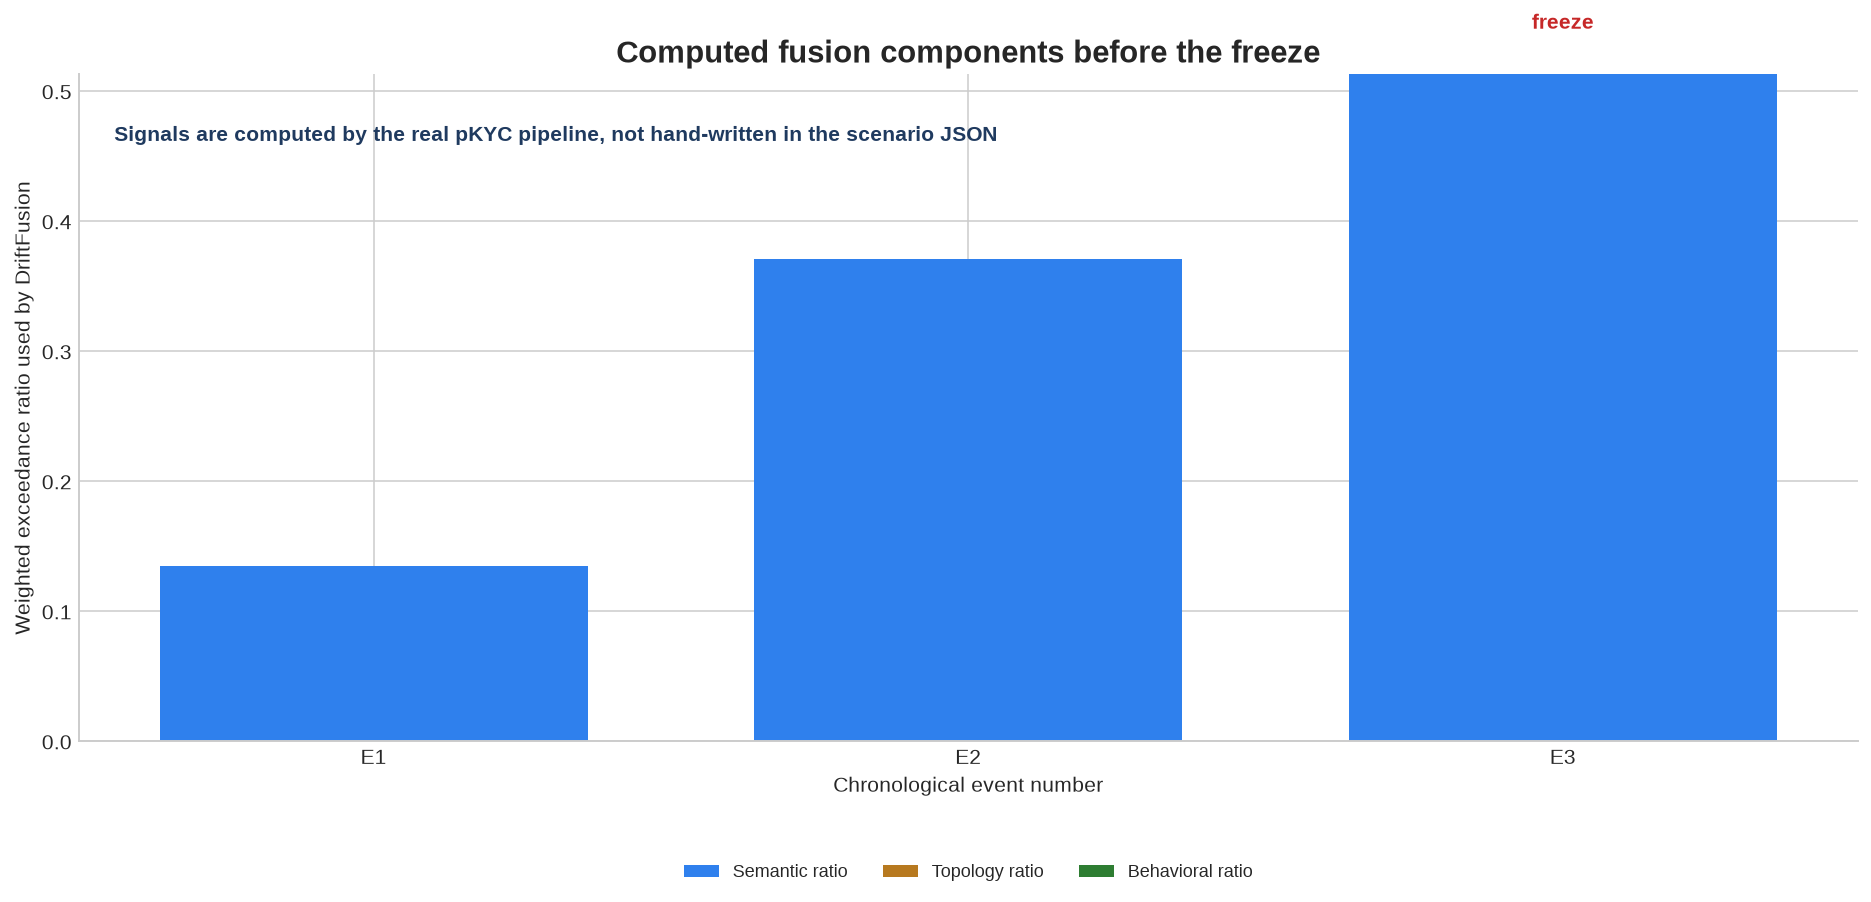

In [11]:
fig, ax = plt.subplots(figsize=(13.5, 6.5))

width = 0.72
x = scenario["index"].to_numpy()
sem = scenario["semantic_ratio"].to_numpy()
topo = scenario["topology_ratio"].to_numpy()
tx = scenario["behavioral_ratio"].to_numpy()

ax.bar(x, sem, width, label="Semantic ratio", color=COLORS["blue"])
ax.bar(x, topo, width, bottom=sem, label="Topology ratio", color=COLORS["amber"])
ax.bar(x, tx, width, bottom=sem + topo, label="Behavioral ratio", color=COLORS["green"])
ax.set_title("Computed fusion components before the freeze")
ax.set_xlabel("Chronological event number")
ax.set_ylabel("Weighted exceedance ratio used by DriftFusion")
ax.set_xticks(x)
ax.set_xticklabels([f"E{int(i)}" for i in x])
legend_below(ax, ncol=3, fontsize=9)

alarm_idx = scenario_meta.get("alarm_event_index")
for _, row in scenario.iterrows():
    if row["trigger"] and alarm_idx and row["index"] == alarm_idx:
        total = sem[int(row["index"]) - 1] + topo[int(row["index"]) - 1] + tx[int(row["index"]) - 1]
        ax.text(row["index"], total + 0.035, "freeze", ha="center", color=COLORS["red"], fontweight="bold")

ax.text(
    0.02,
    0.9,
    "Signals are computed by the real pKYC pipeline, not hand-written in the scenario JSON",
    transform=ax.transAxes,
    fontweight="bold",
    color=COLORS["navy"],
)
savefig("06_microstrategy_fusion_components", bottom=0.2)
plt.show()

In [12]:
timeline = scenario[["index", "date", "title", "source", "combined_risk", "trigger", "url"]].copy()
timeline["combined_risk"] = timeline["combined_risk"].map(lambda x: f"{x:.3f}")
timeline

,index,date,title,source,combined_risk,trigger,url
0,1,2020-07-28,MicroStrategy announces capital allocation str...,SEC 8-K / Q2 2020 earnings release,0.135,False,https://www.sec.gov/Archives/edgar/data/105044...
1,2,2020-08-11,MicroStrategy adopts Bitcoin as primary treasu...,SEC 8-K / press release,0.371,False,https://www.sec.gov/Archives/edgar/data/105044...
2,3,2020-12-11,MicroStrategy closes $650M convertible note of...,Strategy press release / SEC 8-K,0.513,True,https://www.strategy.com/press/microstrategy-c...


### Recommendation after improving the data

The best evaluation package for the demo is now **two-track**:

1. **Shock benchmark** (`data/evaluation_lead_time.json`): proves same-day reaction, low cost and early stopping on catastrophic public events.
2. **Historical replay** (`data/scenarios/*.json` + `run_scenario_demo`): the JSON only curates dated facts; semantic, topology and behavioural signals are computed by the same pipeline as `run_demo`. Replay resets topology to onboarding Layer-2 risk, seeds drift detectors from that baseline, and supports optional `burn_in` precursor events.

This is stronger than pretending the live RSS snapshot predicts fraud early. It is also honest: we do not hand-write `semantic_signal` / `topology_signal` / `behavioral_signal` for the presentation charts.

For a production-grade evaluation, the next data step is to store monthly or weekly OSINT snapshots and replay the same scenarios with the actual signals available at each point in time.

## Full historical scenario battery

Además de MicroStrategy, hay escenarios evidence-backed para los 7 clientes. No todos representan el mismo fenómeno:

- **Slow/structural drift:** Wirecard, MicroStrategy, OpenAI.
- **Rapid deterioration:** FTX.
- **Sanctions escalation:** VTB, Gazprombank, Surgutneftegas.

La evaluación buena para el jurado no es decir que todos son “drift” idéntico, sino que el mismo motor secuencial puede replayear diferentes trayectorias de riesgo con señales **computadas** por el pipeline real.

In [13]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_scenario_demo import replay_scenario

all_events_csv = ROOT / "data" / "scenario_replay_events.csv"
all_summary_csv = ROOT / "data" / "scenario_replay_summary.csv"
scenario_dir = ROOT / "data" / "scenarios"

# Keep notebook reruns stable for the demo. The CSVs are the persisted output of
# the honest replay; set this flag to True only when intentionally regenerating.
REPLAY_SCENARIO_BATTERY = False

if REPLAY_SCENARIO_BATTERY:
    results = [replay_scenario(path) for path in sorted(scenario_dir.glob("*.json"))]
    all_events = pd.concat(
        [pd.DataFrame({**row, "scenario_id": result["scenario_id"], "client": result["client"]} for row in result["events"])
         for result in results],
        ignore_index=True,
    )
    all_summary = pd.DataFrame(
        [
            {
                "scenario_id": result["scenario_id"],
                "client": result["client"],
                "alarm_event_index": result["alarm_event_index"],
                "alarm_date": result["alarm_date"],
                "alarm_title": result["alarm_title"],
                "events_total": len(result["events"]),
                "pre_alarm_events": len([e for e in result["events"] if result["alarm_event_index"] is None or e["index"] < result["alarm_event_index"]]),
                "risk_before_alarm": next((e["combined_risk"] for e in result["events"] if result["alarm_event_index"] and e["index"] == result["alarm_event_index"] - 1), 0.0),
                "alarm_risk": next((e["combined_risk"] for e in result["events"] if result["alarm_event_index"] and e["index"] == result["alarm_event_index"]), None),
                "description": result["description"],
            }
            for result in results
        ]
    )
    all_events.to_csv(all_events_csv, index=False)
    all_summary.to_csv(all_summary_csv, index=False)
else:
    all_events = pd.read_csv(all_events_csv)
    all_summary = pd.read_csv(all_summary_csv)

scenario_label_map = {
    "wirecard_drift": "Wirecard",
    "ftx_rapid_deterioration": "FTX",
    "microstrategy_drift": "MicroStrategy",
    "vtb_sanctions_escalation": "VTB",
    "gazprombank_sanctions_escalation": "Gazprombank",
    "surgutneftegas_sanctions_escalation": "Surgut",
    "openai_regulatory_drift": "OpenAI",
}
all_events["short_label"] = all_events["scenario_id"].map(scenario_label_map)
all_summary["short_label"] = all_summary["scenario_id"].map(scenario_label_map)
all_summary[["short_label", "alarm_event_index", "alarm_date", "risk_before_alarm", "alarm_risk", "description"]]

[GRAPH MUTATION] New Entity Detected: 'Alameda Research' -> registered as DYN_COMPANY_001 (GDPR token MASKED_COMPANY_006)
[GRAPH MUTATION] Added Directed Edge: DYN_COMPANY_001 --[ASSOCIATED_WITH (w=0.1)]--> COMPANY_2
[STREAMING EVENT 1/6] Title: CoinDesk reports Alameda Research balance sheet heavily depends on FTX's FTT token | Semantic Dist: 0.4822 | Contagion Score: 0.0000 | Combined Risk: 0.1578 [TRIGGER FIRED: FALSE]
[GRAPH MUTATION] New Entity Detected: 'Binance' -> registered as DYN_COMPANY_002 (GDPR token MASKED_COMPANY_007)
[GRAPH MUTATION] Added Directed Edge: DYN_COMPANY_002 --[ASSOCIATED_WITH (w=0.1)]--> COMPANY_2
[STREAMING EVENT 2/6] Title: Binance says it will liquidate remaining FTT holdings tied to FTX after CoinDesk revelations | Semantic Dist: 0.5148 | Contagion Score: 0.0000 | Combined Risk: 0.3017 [TRIGGER FIRED: FALSE]
[GRAPH MUTATION] Added Directed Edge: DYN_COMPANY_002 --[ASSOCIATED_WITH (w=0.1)]--> COMPANY_2
[STREAMING EVENT 3/6] Title: FTX faces withdrawal pr

,short_label,alarm_event_index,alarm_date,risk_before_alarm,alarm_risk,description
0,FTX,4.0,2022-11-09,0.4807,0.5263,Evidence-backed rapid deterioration replay: no...
1,Gazprombank,4.0,2022-03-31,0.4404,0.5981,Energy-payment exposure replay showing Gazprom...
2,MicroStrategy,3.0,2020-12-11,0.3713,0.5132,Evidence-backed as-of replay showing gradual K...
3,OpenAI,NaN,NaN,0.0000,NaN,Chronological watchlist example (6 stream even...
4,Surgut,5.0,2025-01-10,0.1665,0.5201,Russian energy-sector escalation replay from s...
5,VTB,5.0,2022-03-02,0.3926,0.5504,Sanctions escalation replay from 2014 sectoral...
6,Wirecard,6.0,2020-06-25,0.4876,0.5608,Evidence-backed replay showing accounting-risk...


saved: data/ppt_figures/07_all_scenario_risk_curves.png


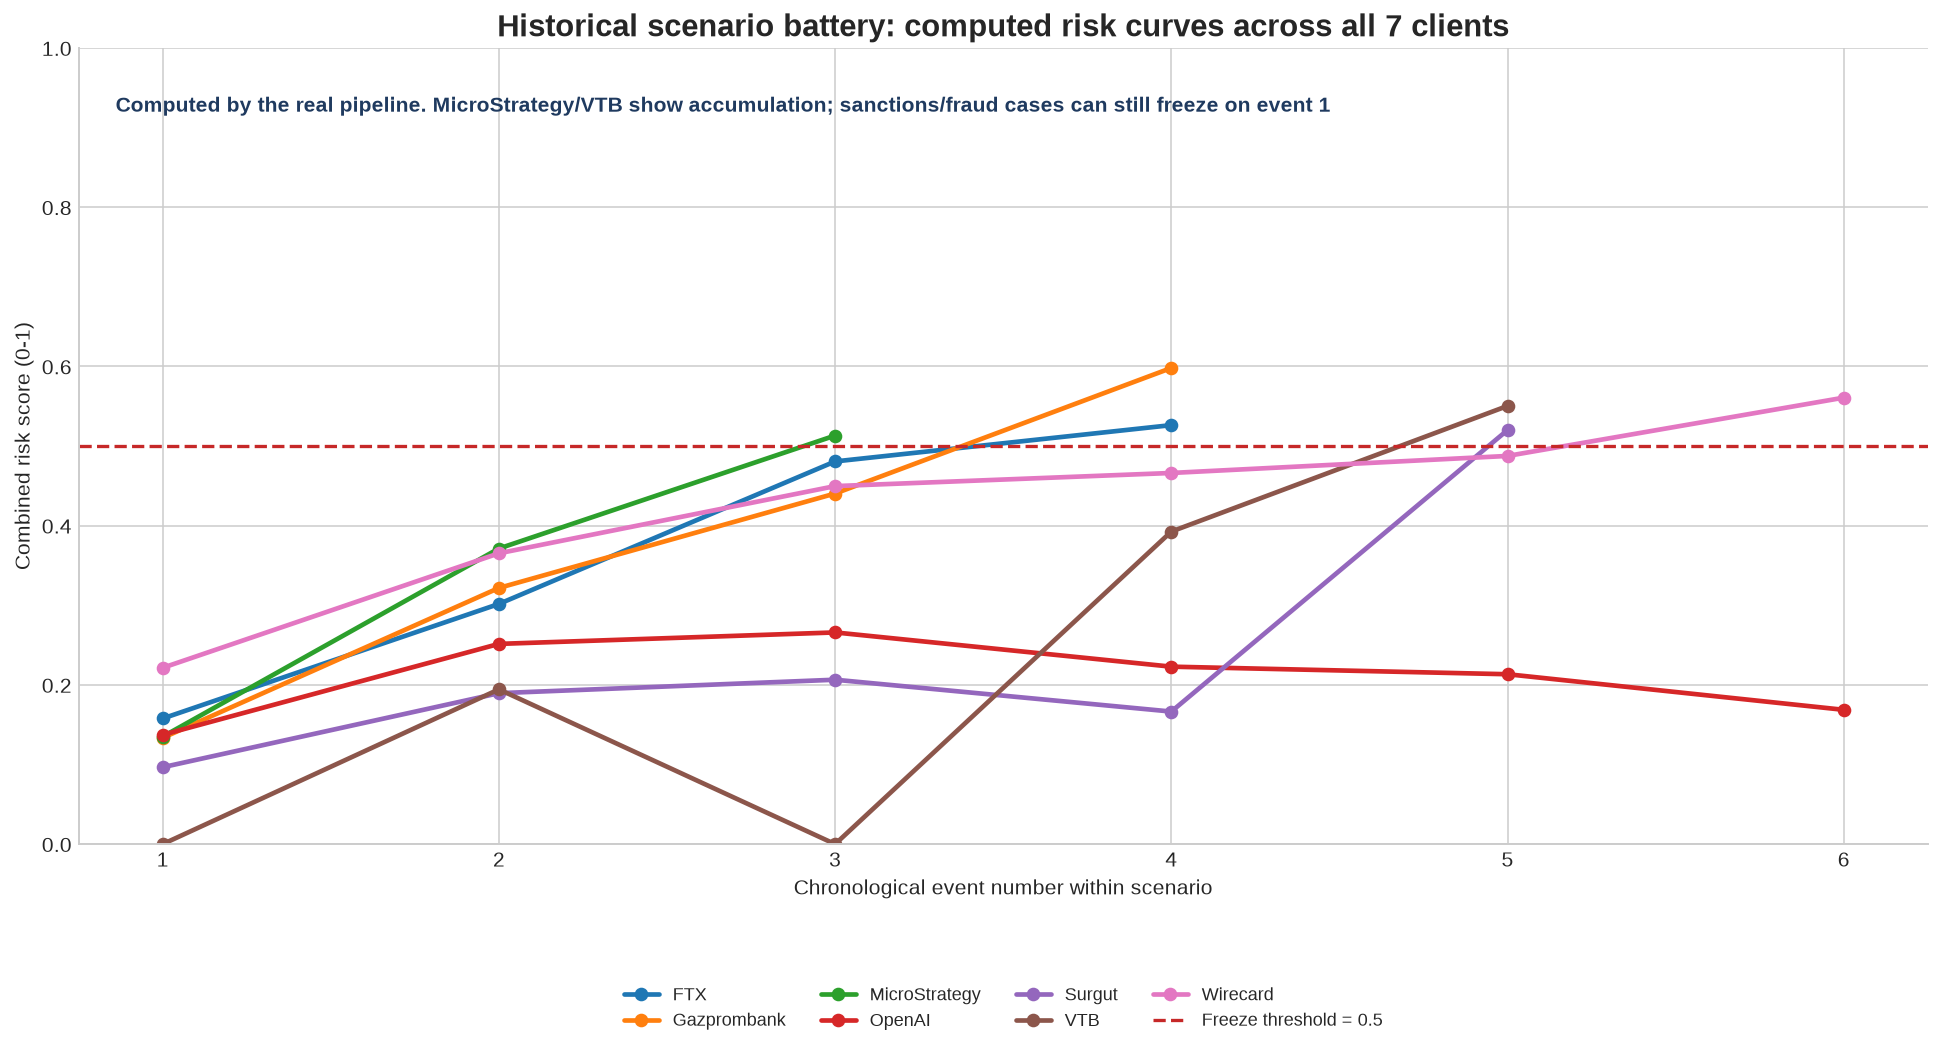

In [14]:
fig, ax = plt.subplots(figsize=(14, 7.5))

for label, group in all_events.groupby("short_label"):
    group = group.sort_values("index")
    ax.plot(group["index"], group["combined_risk"], marker="o", linewidth=2.4, label=label)

ax.axhline(0.5, color=COLORS["red"], linestyle="--", linewidth=1.7, label="Freeze threshold = 0.5")
ax.set_title("Historical scenario battery: computed risk curves across all 7 clients")
ax.set_xlabel("Chronological event number within scenario")
ax.set_ylabel("Combined risk score (0-1)")
ax.set_xticks(sorted(all_events["index"].unique()))
ax.set_ylim(0, 1.0)
legend_below(ax, ncol=4, fontsize=9)
ax.text(
    0.02,
    0.92,
    "Computed by the real pipeline. MicroStrategy/VTB show accumulation; sanctions/fraud cases can still freeze on event 1",
    transform=ax.transAxes,
    fontweight="bold",
    color=COLORS["navy"],
)

savefig("07_all_scenario_risk_curves", bottom=0.24)
plt.show()

saved: data/ppt_figures/08_alarm_event_and_pre_alarm_risk.png


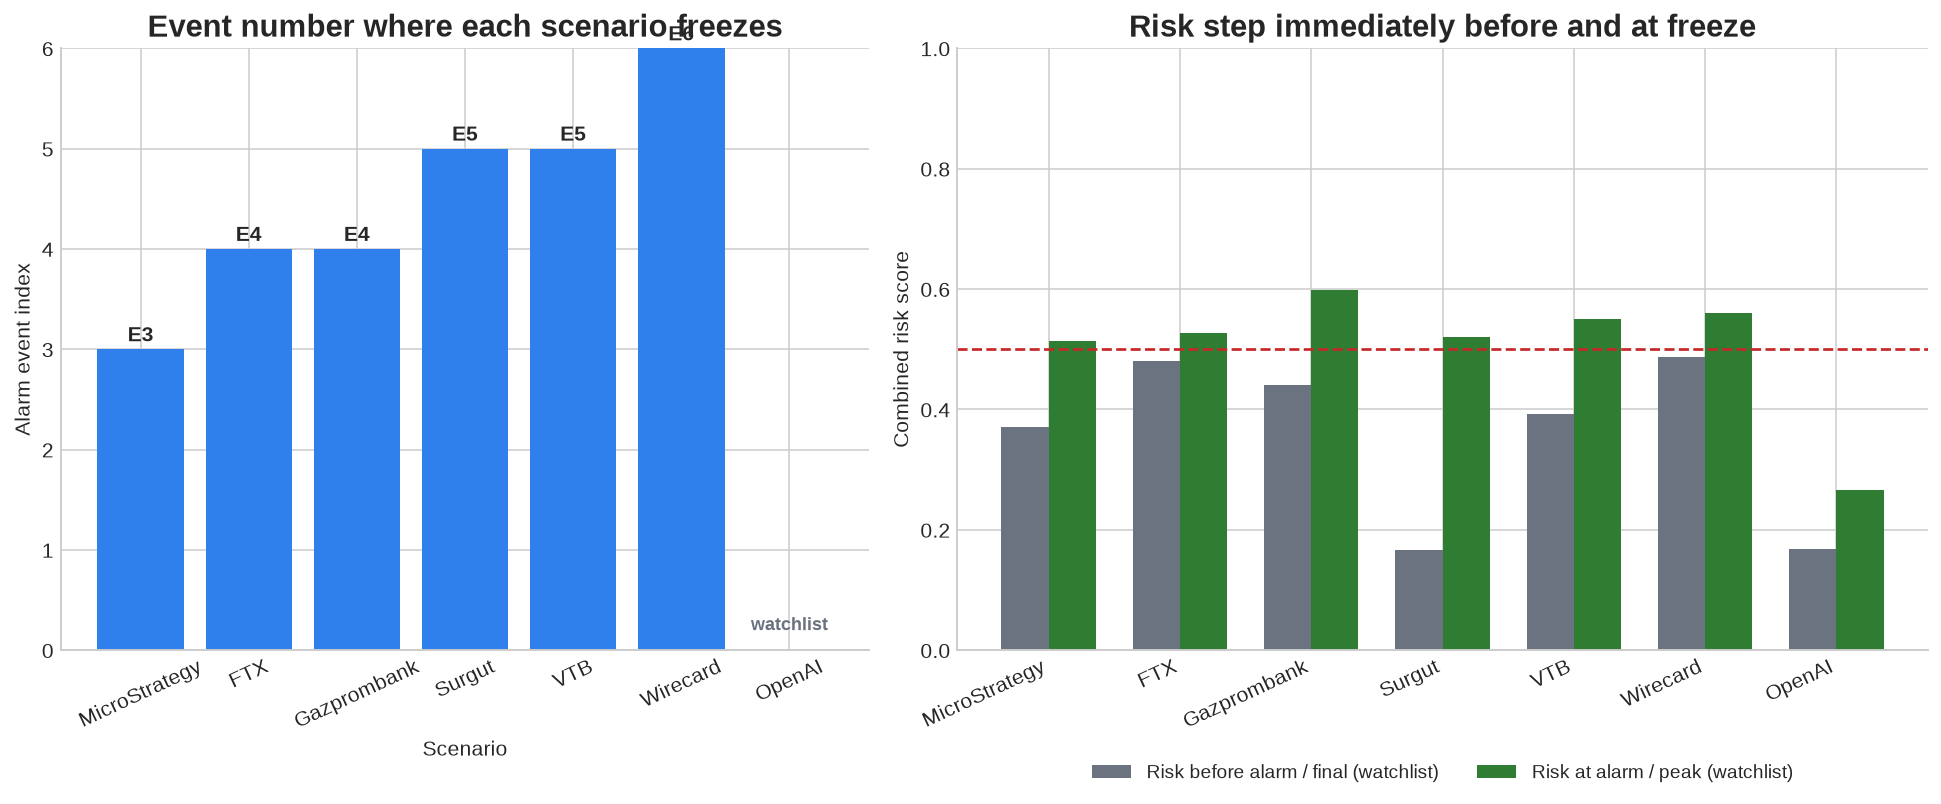

In [16]:
summary_plot = all_summary.sort_values("alarm_event_index", na_position="last").copy()
peak_by_label = all_events.groupby("short_label")["combined_risk"].max()
final_by_label = all_events.sort_values("index").groupby("short_label")["combined_risk"].last()
summary_plot["peak_risk"] = summary_plot["short_label"].map(peak_by_label)
summary_plot["final_risk"] = summary_plot["short_label"].map(final_by_label)
has_alarm = summary_plot["alarm_event_index"].notna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.0, 1.2]})

freeze_heights = summary_plot["alarm_event_index"].fillna(0)
bar_colors = [COLORS["blue"] if fired else COLORS["gray"] for fired in has_alarm]
axes[0].bar(summary_plot["short_label"], freeze_heights, color=bar_colors)
axes[0].set_title("Event number where each scenario freezes")
axes[0].set_ylabel("Alarm event index")
axes[0].set_xlabel("Scenario")
axes[0].set_ylim(0, 6)
axes[0].tick_params(axis="x", rotation=25)
for idx, row in enumerate(summary_plot.itertuples()):
    if pd.notna(row.alarm_event_index):
        axes[0].text(idx, row.alarm_event_index + 0.08, f"E{int(row.alarm_event_index)}", ha="center", fontweight="bold")
    else:
        axes[0].text(idx, 0.2, "watchlist", ha="center", fontsize=9, fontweight="bold", color=COLORS["gray"])

x = np.arange(len(summary_plot))
risk_before = np.where(has_alarm, summary_plot["risk_before_alarm"], summary_plot["final_risk"])
risk_at = np.where(has_alarm, summary_plot["alarm_risk"], summary_plot["peak_risk"])
axes[1].bar(x - 0.18, risk_before, 0.36, color=COLORS["gray"], label="Risk before alarm / final (watchlist)")
axes[1].bar(x + 0.18, risk_at, 0.36, color=COLORS["green"], label="Risk at alarm / peak (watchlist)")
axes[1].axhline(0.5, color=COLORS["red"], linestyle="--", linewidth=1.4)
axes[1].set_title("Risk step immediately before and at freeze")
axes[1].set_ylabel("Combined risk score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_plot["short_label"], rotation=25, ha="right")
axes[1].set_ylim(0, 1.0)
legend_below(axes[1], ncol=2)

savefig("08_alarm_event_and_pre_alarm_risk", bottom=0.22)
plt.show()

### Final recommendation

For the presentation, use the scenarios as a **taxonomy**, not as seven identical proofs:

1. **Best mathematical drift demo:** MicroStrategy. Slow strategic drift from BI software to leveraged Bitcoin treasury, with computed signals.
2. **Best fraud shock demo:** Wirecard. The first investigative article can already freeze the account when topology + semantics are strong.
3. **Best rapid deterioration demo:** FTX. Not slow drift, but proves event-sequence memory during a liquidity spiral.
4. **Best global contagion demo:** VTB + Gazprombank via `Government of Russia`.
5. **Best watchlist / sub-threshold demo:** OpenAI. Chronological regulatory and governance pressure accumulates gradually (peak ~0.27) without crossing the freeze threshold — useful to show the engine monitoring without over-triggering.

The improved result is now more honest: the JSON curates the timeline, but the engine computes the risk. MicroStrategy is the cleanest gradual freeze case; sanctions and fraud cases may still freeze on event 1 because the first public fact is already material; OpenAI shows a watchlist path where risk stays below threshold.